# **LESSON 2 (Logistic Problem):**

By Diego Fiz García

______________________________________________________________________________________________________________________________________________

# **Logistics Transportation Optimization Problem**

___________________________________________________________________________________

### Problem Description

A company must distribute products from **2 warehouses** (Warehouse 1 and Warehouse 2) to **3 stores** (Store 1, Store 2, and Store 3), minimizing the total transportation cost.

### Decision Variables

The variables $x_{ij}$ represent the quantity of product to transport from warehouse $i$ to store $j$:

- $x_{11}$: quantity transported from Warehouse 1 to Store 1
- $x_{12}$: quantity transported from Warehouse 1 to Store 2
- $x_{13}$: quantity transported from Warehouse 1 to Store 3
- $x_{21}$: quantity transported from Warehouse 2 to Store 1
- $x_{22}$: quantity transported from Warehouse 2 to Store 2
- $x_{23}$: quantity transported from Warehouse 2 to Store 3

### Objective Function

Minimize the total transportation cost $Z$:

$$\min Z = 4x_{11} + 6x_{12} + 9x_{13} + 5x_{21} + 4x_{22} + 7x_{23}$$

where the coefficients represent the unit transportation cost (in euros) for each route.

### Equality Constraints (Store Demands)

The stores must receive exactly the demanded quantity:

$$x_{11} + x_{21} = 80 \quad \text{(Demand for Store 1)}$$

$$x_{12} + x_{22} = 70 \quad \text{(Demand for Store 2)}$$

$$x_{13} + x_{23} = 50 \quad \text{(Demand for Store 3)}$$

### Inequality Constraints (Warehouse Supply)

The warehouses cannot ship more than their available capacity:

$$x_{11} + x_{12} + x_{13} \leq 100 \quad \text{(Supply from Warehouse 1)}$$

$$x_{21} + x_{22} + x_{23} \leq 120 \quad \text{(Supply from Warehouse 2)}$$

### Non-Negativity Constraints

All variables must be non-negative:

$$x_{ij} \geq 0 \quad \forall i \in \{1,2\}, \, j \in \{1,2,3\}$$

### Problem Parameters

#### Transportation costs (€/unit):

- Warehouse 1 → Store 1: 4 €
- Warehouse 1 → Store 2: 6 €
- Warehouse 1 → Store 3: 9 €
- Warehouse 2 → Store 1: 5 €
- Warehouse 2 → Store 2: 4 €
- Warehouse 2 → Store 3: 7 €

#### Demands (units):

- Store 1: 80 units
- Store 2: 70 units
- Store 3: 50 units

#### Supply (units):

- Warehouse 1: 100 units maximum
- Warehouse 2: 120 units maximum

### Matrix Formulation

The problem can be expressed in matrix form:

#### Cost vector:

$$\mathbf{c} = [4, 6, 9, 5, 4, 7]^T$$

#### Equality constraint matrix:

$$\mathbf{A}_{eq} = \begin{bmatrix} 1 & 0 & 0 & 1 & 0 & 0 \\ 0 & 1 & 0 & 0 & 1 & 0 \\ 0 & 0 & 1 & 0 & 0 & 1 \end{bmatrix}, \quad \mathbf{b}_{eq} = \begin{bmatrix} 80 \\ 70 \\ 50 \end{bmatrix}$$

#### Inequality constraint matrix:

$$\mathbf{A}_{ub} = \begin{bmatrix} 1 & 1 & 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & 1 & 1 \end{bmatrix}, \quad \mathbf{b}_{ub} = \begin{bmatrix} 100 \\ 120 \end{bmatrix}$$

This is a **linear programming** problem solved using the simplex method or equivalent algorithms, seeking to minimize total transportation cost while satisfying all demands without exceeding warehouse capacities.

### Solution:

Optimización exitosa!
Coste óptimo: 950.00€
Solución óptima:
  x11=80.00, x12=-0.00, x13=0.00
  x21=0.00, x22=70.00, x23=50.00


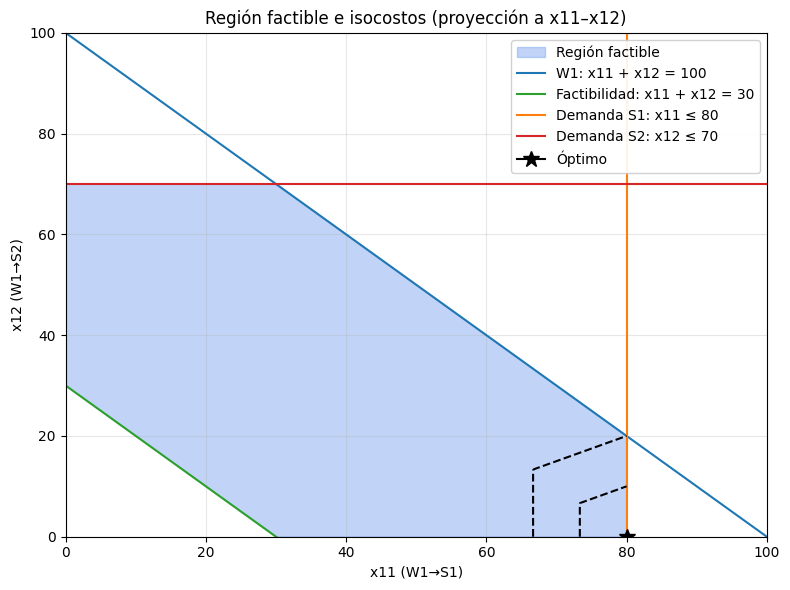

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog


# ----------------- Modelo base (idéntico al propuesto) -----------------
c = [4, 6, 9, 5, 4, 7]  # x11, x12, x13, x21, x22, x23
A_eq = [
    [1, 0, 0, 1, 0, 0],  # x11 + x21 = 80 (Tienda 1)
    [0, 1, 0, 0, 1, 0],  # x12 + x22 = 70 (Tienda 2)
    [0, 0, 1, 0, 0, 1],  # x13 + x23 = 50 (Tienda 3)
]
b_eq = [80, 70, 50]
A_ub = [
    [1, 1, 1, 0, 0, 0],  # W1: x11 + x12 + x13 <= 100
    [0, 0, 0, 1, 1, 1],  # W2: x21 + x22 + x23 <= 120
]
b_ub = [100, 120]
bounds = [(0, None)] * 6

res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
              bounds=bounds, method='highs')

if not res.success:
    raise ValueError(f"La optimización falló: {res.message}")

print("Optimización exitosa!")
print(f"Coste óptimo: {res.fun:.2f}€")
print(f"Solución óptima:")
print(f"  x11={res.x[0]:.2f}, x12={res.x[1]:.2f}, x13={res.x[2]:.2f}")
print(f"  x21={res.x[3]:.2f}, x22={res.x[4]:.2f}, x23={res.x[5]:.2f}")


# ----------------- Proyección 2D a (x11, x12) -----------------
def cost_and_mask_grid(nx=401, ny=351):
    """Calcula el coste y la máscara de factibilidad en la proyección 2D"""
    x1 = np.linspace(0, 80, nx)      # x11
    x2 = np.linspace(0, 70, ny)      # x12
    X, Y = np.meshgrid(x1, x2)
    s = X + Y
    lower = np.maximum(0, 80 - s)        # t >= lower
    upper = np.minimum(50, 100 - s)      # t <= upper
    feasible = (s >= 30) & (s <= 100) & (lower <= upper)
    t_star = lower
    Z = 1030 - X + 2*Y + 2*t_star
    Z[~feasible] = np.nan
    return X, Y, Z, feasible


X, Y, Z, feasible = cost_and_mask_grid()


# ----------------- Región factible (como polígono) -----------------
# Vértices del polígono proyectado
poly = np.array([
    [30, 0],   # intersección x2=0 con s=30
    [80, 0],   # cota x11<=80
    [80, 20],  # intersección x11=80 con s=100
    [30, 70],  # intersección x2=70 con s=100
    [0, 70],   # cota x12<=70
    [0, 30],   # intersección x11=0 con s=30
])
px, py = poly[:,0], poly[:,1]


# ----------------- Plot -----------------
fig, ax = plt.subplots(figsize=(8,6))

# Sombreado factible
ax.fill(px, py, color='cornflowerblue', alpha=0.4, label='Región factible')

# Rectas de contorno de restricciones
x = np.linspace(0, 100, 500)
ax.plot(x, 100 - x, color='tab:blue', label='W1: x11 + x12 = 100')
ax.plot(x, 30 - x, color='tab:green', label='Factibilidad: x11 + x12 = 30')
ax.axvline(80, color='tab:orange', label='Demanda S1: x11 ≤ 80')
ax.axhline(70, color='tab:red', label='Demanda S2: x12 ≤ 70')

# Isocostos (contornos del coste)
levels = [950, 970, 990]
CS = ax.contour(X, Y, Z, levels=levels, colors='black', linestyles='dashed')
ax.clabel(CS, inline=True, fmt='Coste: %d', fontsize=9)

# Punto óptimo
x11_opt, x12_opt = res.x[0], res.x[1]
ax.plot([x11_opt], [x12_opt], marker='*', color='black', ms=12, label='Óptimo')

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('x11 (W1→S1)')
ax.set_ylabel('x12 (W1→S2)')
ax.set_title('Región factible e isocostos (proyección a x11–x12)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

Coste óptimo base: 950.0
Precios sombra (igualdades, demandas): [4. 6. 9.]
Precios sombra (desigualdades, ofertas): [-0. -2.]
Pendientes finitas (eq)      : [4. 5. 8.]
Precios sombra eqlin.marginals: [4. 6. 9.]
Pendientes finitas (ub)      : [ 0. -1.]
Precios sombra ineqlin.marginals: [-0. -2.]


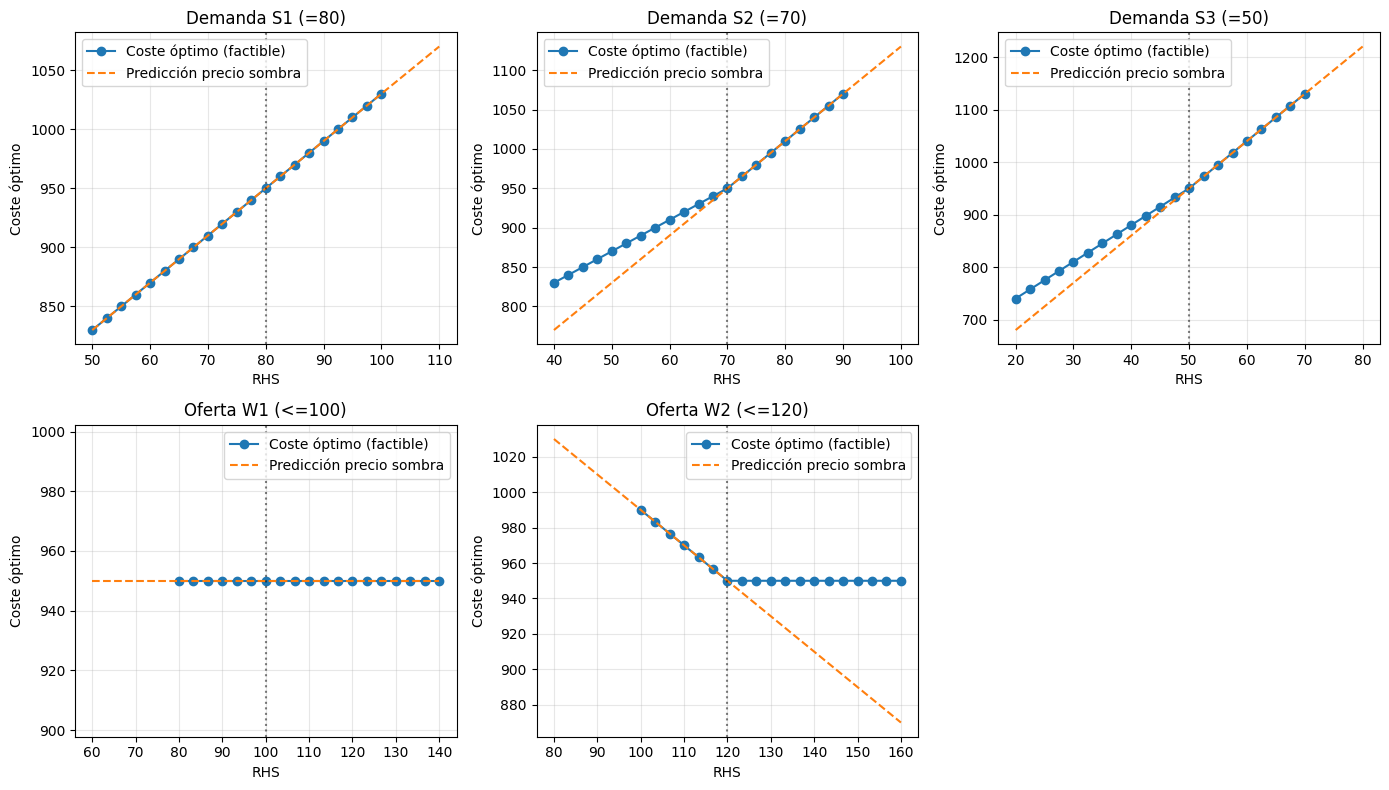

In [ ]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

# ---------- Datos base (tu modelo) ----------
c = [4, 6, 9, 5, 4, 7]  # x11, x12, x13, x21, x22, x23

A_eq = [
    [1, 0, 0, 1, 0, 0],  # x11 + x21 = 80 (Tienda 1)
    [0, 1, 0, 0, 1, 0],  # x12 + x22 = 70 (Tienda 2)
    [0, 0, 1, 0, 0, 1],  # x13 + x23 = 50 (Tienda 3)
]
b_eq = [80, 70, 50]

A_ub = [
    [1, 1, 1, 0, 0, 0],  # x11 + x12 + x13 <= 100 (Almacén 1)
    [0, 0, 0, 1, 1, 1],  # x21 + x22 + x23 <= 120 (Almacén 2)
]
b_ub = [100, 120]

bounds = [(0, None)] * 6

def solve_lp(b_eq_override=None, b_ub_override=None):
    beq = b_eq if b_eq_override is None else b_eq_override
    bub = b_ub if b_ub_override is None else b_ub_override
    res = linprog(c, A_ub=A_ub, b_ub=bub, A_eq=A_eq, b_eq=beq,
                  bounds=bounds, method='highs')
    return res

# ---------- Solución base y precios sombra ----------
base_res = solve_lp()
assert base_res.success, "El problema base no es óptimo"

print("Coste óptimo base:", base_res.fun)
print("Precios sombra (igualdades, demandas):", base_res.eqlin.marginals)
print("Precios sombra (desigualdades, ofertas):", base_res.ineqlin.marginals)

# ---------- Función para barrer un RHS y medir coste ----------
def sweep_rhs(is_eq, idx, rhs_values):
    costs = []
    feas = []
    for rhs in rhs_values:
        if is_eq:
            beq_new = list(b_eq)
            beq_new[idx] = rhs
            res = solve_lp(b_eq_override=beq_new)
        else:
            bub_new = list(b_ub)
            bub_new[idx] = rhs
            res = solve_lp(b_ub_override=bub_new)
        feas.append(res.success)
        costs.append(res.fun if res.success else np.nan)
    return np.array(costs), np.array(feas)

# ---------- Rango de barrido (evitar extremos muy inviables) ----------
base_cost = base_res.fun
eq_names = ["Demanda S1 (=80)", "Demanda S2 (=70)", "Demanda S3 (=50)"]
ub_names = ["Oferta W1 (<=100)", "Oferta W2 (<=120)"]

eq_bases = np.array(b_eq)
ub_bases = np.array(b_ub)

# Elegir rangos moderados alrededor del punto base
eq_grids = [np.linspace(eq_bases[i]-30, eq_bases[i]+30, 25) for i in range(3)]
ub_grids = [np.linspace(ub_bases[i]-40, ub_bases[i]+40, 25) for i in range(2)]

# ---------- Barridos ----------
eq_costs = []
eq_feas = []
for i in range(3):
    costs, feas = sweep_rhs(is_eq=True, idx=i, rhs_values=eq_grids[i])
    eq_costs.append(costs)
    eq_feas.append(feas)

ub_costs = []
ub_feas = []
for i in range(2):
    costs, feas = sweep_rhs(is_eq=False, idx=i, rhs_values=ub_grids[i])
    ub_costs.append(costs)
    ub_feas.append(feas)

# ---------- Comprobación de pendiente local vs precio sombra ----------
eps = 1e-3
eq_slopes_fd = []
for i in range(3):
    beq_plus = list(b_eq); beq_plus[i] += eps
    beq_minus = list(b_eq); beq_minus[i] -= eps
    z_plus = solve_lp(b_eq_override=beq_plus).fun
    z_minus = solve_lp(b_eq_override=beq_minus).fun
    eq_slopes_fd.append((z_plus - z_minus) / (2*eps))
eq_slopes_fd = np.array(eq_slopes_fd)

# Desigualdades (oferta)
ub_slopes_fd = []
for i in range(2):
    bub_plus = list(b_ub); bub_plus[i] += eps
    bub_minus = list(b_ub); bub_minus[i] -= eps
    z_plus = solve_lp(b_ub_override=bub_plus).fun
    z_minus = solve_lp(b_ub_override=bub_minus).fun
    ub_slopes_fd.append((z_plus - z_minus) / (2*eps))
ub_slopes_fd = np.array(ub_slopes_fd)

print("Pendientes finitas (eq)      :", eq_slopes_fd)
print("Precios sombra eqlin.marginals:", base_res.eqlin.marginals)
print("Pendientes finitas (ub)      :", ub_slopes_fd)
print("Precios sombra ineqlin.marginals:", base_res.ineqlin.marginals)

# ---------- Gráficos ----------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

# Dibujar demandas (igualdades)
for i in range(3):
    ax = axes[i]
    x = eq_grids[i]
    y = eq_costs[i]
    feas = eq_feas[i]
    ax.plot(x[feas], y[feas], 'o-', label='Coste óptimo (factible)')
    m = base_res.eqlin.marginals[i]
    x0 = eq_bases[i]
    y0 = base_cost
    x_line = np.array([x.min(), x.max()])
    y_line = y0 + m*(x_line - x0)
    ax.plot(x_line, y_line, '--', label='Predicción precio sombra')
    ax.axvline(x0, color='k', alpha=0.5, linestyle=':')
    ax.set_title(eq_names[i])
    ax.set_xlabel('RHS')
    ax.set_ylabel('Coste óptimo')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Dibujar ofertas (desigualdades)
for i in range(2):
    ax = axes[3+i]
    x = ub_grids[i]
    y = ub_costs[i]
    feas = ub_feas[i]
    ax.plot(x[feas], y[feas], 'o-', label='Coste óptimo (factible)')
    m = base_res.ineqlin.marginals[i]
    x0 = ub_bases[i]
    y0 = base_cost
    x_line = np.array([x.min(), x.max()])
    y_line = y0 + m*(x_line - x0)
    ax.plot(x_line, y_line, '--', label='Predicción precio sombra')
    ax.axvline(x0, color='k', alpha=0.5, linestyle=':')
    ax.set_title(ub_names[i])
    ax.set_xlabel('RHS')
    ax.set_ylabel('Coste óptimo')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.show()